<a href="https://colab.research.google.com/github/rcNibedita/De-Novo-Gen/blob/main/02_Exploratory_Analysis_of_TAK1_Inhibitors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount the Drive (Repeat everytime you create a notebook)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Relocate to the working directory
!ls "/content/drive/MyDrive/De-Novo"
%cd "/content/drive/MyDrive/De-Novo"
!pwd

01_Preprocess_ChEMBL_TAK1_Bioactivity_Data.ipynb  TAK1_clean_canonical.csv
02_Exploratory_Analysis_of_TAK1_Inhibitors.ipynb  TAK1_clean.csv
chembl_raw.csv
/content/drive/MyDrive/De-Novo
/content/drive/MyDrive/De-Novo


In [ ]:
# ============================================================
# Install Required Packages
# ============================================================

!pip -q install rdkit seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 48.3 MB/s eta 0:00:00


In [ ]:
# ============================================================
# Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
from rdkit.Chem import Crippen
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import QED

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# ============================================================
# Load TAK1 Clean Dataset
# ============================================================

df = pd.read_csv("TAK1_clean_canonical.csv")

print("Dataset loaded.")
print("Total molecules:", len(df))

df.head()

Dataset loaded.
Total molecules: 178


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value,Canonical_SMILES
0,CHEMBL2407792,NaN,NaN,446.47,0,4.03,12z,CC(=O)N1CCC(n2cc(-c3cnc(N)c4oc(-c5cccc([N+](=O...,IC50,'=',...,1,Scientific Literature,Bioorg Med Chem Lett,2013,CHEMBL3308372,NaN,NaN,NaN,0.200,CC(=O)N1CCC(n2cc(-c3cnc(N)c4oc(-c5cccc([N+](=O...
1,CHEMBL2407759,NaN,NaN,459.54,0,4.13,12az,CC(=O)N1CCC(n2cc(-c3cnc(N)c4oc(-c5cccc6nnsc56)...,IC50,'=',...,1,Scientific Literature,Bioorg Med Chem Lett,2013,CHEMBL3308372,NaN,NaN,NaN,0.012,CC(=O)N1CCC(n2cc(-c3cnc(N)c4oc(-c5cccc6nnsc56)...
2,CHEMBL4446434,NaN,NaN,358.20,0,4.59,4,COc1cc(Br)cc2[nH]cc(-c3cnc(-c4ccc[nH]4)o3)c12,IC50,'=',...,1,Scientific Literature,J Med Chem,2019,NaN,NaN,NaN,NaN,1.000,COc1cc(Br)cc2[nH]cc(-c3cnc(-c4ccc[nH]4)o3)c12
3,CHEMBL2407763,NaN,NaN,457.56,1,5.34,12bd,CC(=O)N1CCC(n2cc(-c3cnc(N)c4oc(-c5csc6ccccc56)...,IC50,'=',...,1,Scientific Literature,Bioorg Med Chem Lett,2013,CHEMBL3308372,NaN,NaN,NaN,0.440,CC(=O)N1CCC(n2cc(-c3cnc(N)c4oc(-c5csc6ccccc56)...
4,CHEMBL3426225,NaN,NaN,576.63,1,4.16,BDBM50086441,CCn1nc(C#Cc2cc(C(=O)Nc3ccc(CN4CCN(C)CC4)c(C(F)...,IC50,'=',...,37,BindingDB Patent Bioactivity Data,NaN,2019,NaN,NaN,NaN,NaN,61.000,CCn1nc(C#Cc2cc(C(=O)Nc3ccc(CN4CCN(C)CC4)c(C(F)...


In [ ]:
# ============================================================
# Dataset Integrity Checks
# ============================================================

print("Missing values:\n")
print(df.isna().sum())

print("\nDuplicate Canonical SMILES:")
print(df.duplicated(subset="Canonical_SMILES").sum())

Missing values:

Molecule ChEMBL ID              0
Molecule Name                 172
Molecule Max Phase            177
Molecular Weight                0
#RO5 Violations                 0
AlogP                           0
Compound Key                    0
Smiles                          0
Standard Type                   0
Standard Relation               0
Standard Value                  0
Standard Units                  0
pChEMBL Value                   0
Data Validity Comment         178
Comment                       171
Uo Units                        0
Ligand Efficiency BEI           1
Ligand Efficiency LE            1
Ligand Efficiency LLE           1
Ligand Efficiency SEI           1
Potential Duplicate             0
Assay ChEMBL ID                 0
Assay Description               0
Assay Type                      0
BAO Format ID                   0
BAO Label                       0
Assay Organism                  2
Assay Tissue ChEMBL ID        178
Assay Tissue Name             1

In [ ]:
# ============================================================
# Convert SMILES to RDKit Molecules
# ============================================================

df["Mol"] = df["Canonical_SMILES"].apply(Chem.MolFromSmiles)

print("Invalid molecules:", df["Mol"].isna().sum())

Invalid molecules: 0


In [ ]:
# ============================================================
# Calculate Molecular Descriptors
# ============================================================

def calculate_descriptors(mol):
    return pd.Series({
        "MW": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotBonds": Lipinski.NumRotatableBonds(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
        "QED": QED.qed(mol)
    })

descriptor_df = df["Mol"].apply(calculate_descriptors)

df = pd.concat([df, descriptor_df], axis=1)

print("Descriptor calculation complete.")
df.head()

Descriptor calculation complete.


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Mol,MW,LogP,TPSA,HBD,HBA,RotBonds,AromaticRings,HeavyAtoms,QED
0,CHEMBL2407792,NaN,NaN,446.47,0,4.03,12z,CC(=O)N1CCC(n2cc(-c3cnc(N)c4oc(-c5cccc([N+](=O...,IC50,'=',...,<rdkit.Chem.rdchem.Mol object at 0x79c56e2cb1b0>,446.467,4.03210,133.32,1.0,7.0,4.0,4.0,33.0,0.369379
1,CHEMBL2407759,NaN,NaN,459.54,0,4.13,12az,CC(=O)N1CCC(n2cc(-c3cnc(N)c4oc(-c5cccc6nnsc56)...,IC50,'=',...,<rdkit.Chem.rdchem.Mol object at 0x79c5407a6570>,459.535,4.12860,115.96,1.0,8.0,3.0,5.0,33.0,0.431140
2,CHEMBL4446434,NaN,NaN,358.20,0,4.59,4,COc1cc(Br)cc2[nH]cc(-c3cnc(-c4ccc[nH]4)o3)c12,IC50,'=',...,<rdkit.Chem.rdchem.Mol object at 0x79c5407a65e0>,358.195,4.58910,66.84,2.0,3.0,3.0,4.0,22.0,0.562978
3,CHEMBL2407763,NaN,NaN,457.56,1,5.34,12bd,CC(=O)N1CCC(n2cc(-c3cnc(N)c4oc(-c5csc6ccccc56)...,IC50,'=',...,<rdkit.Chem.rdchem.Mol object at 0x79c5407a5ee0>,457.559,5.33860,90.18,1.0,6.0,3.0,5.0,33.0,0.394979
4,CHEMBL3426225,NaN,NaN,576.63,1,4.16,BDBM50086441,CCn1nc(C#Cc2cc(C(=O)Nc3ccc(CN4CCN(C)CC4)c(C(F)...,IC50,'=',...,<rdkit.Chem.rdchem.Mol object at 0x79c5407a66c0>,576.627,4.15512,105.20,2.0,7.0,5.0,4.0,42.0,0.344074


In [ ]:
# ============================================================
# Descriptor Summary Statistics
# ============================================================

df[[
    "MW","LogP","TPSA","HBD","HBA",
    "RotBonds","AromaticRings","QED"
]].describe()

,MW,LogP,TPSA,HBD,HBA,RotBonds,AromaticRings,QED
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,437.271758,3.480911,103.004831,2.140449,6.404494,5.157303,3.213483,0.510245
std,86.800064,1.320990,21.689620,0.835270,1.542022,2.637834,1.052003,0.156907
min,246.270000,0.829500,66.840000,0.000000,2.000000,1.000000,0.000000,0.041306
25%,380.381500,2.368775,86.937500,2.000000,5.250000,3.000000,3.000000,0.401780
50%,450.001000,3.606100,101.640000,2.000000,7.000000,5.000000,3.000000,0.491950
75%,494.887000,4.392215,115.940000,3.000000,7.000000,7.000000,4.000000,0.604856
max,851.475000,6.458920,190.840000,6.000000,13.000000,24.000000,6.000000,0.855213


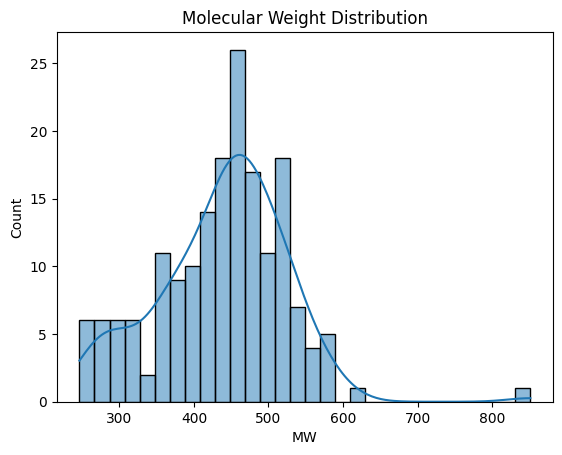

In [ ]:
# ============================================================
# Molecular Weight Distribution
# ============================================================

plt.figure()
sns.histplot(df["MW"], bins=30, kde=True)
plt.title("Molecular Weight Distribution")
plt.xlabel("MW")
plt.ylabel("Count")
plt.show()

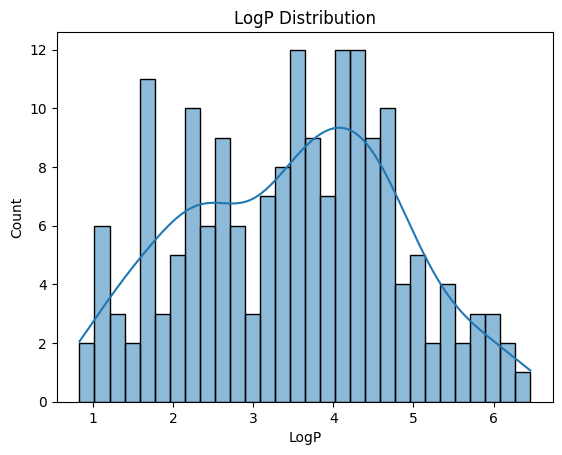

In [ ]:
# ============================================================
# LogP Distribution
# ============================================================

plt.figure()
sns.histplot(df["LogP"], bins=30, kde=True)
plt.title("LogP Distribution")
plt.xlabel("LogP")
plt.show()

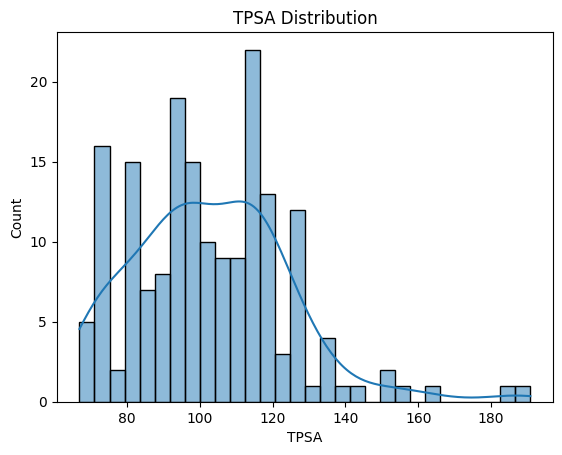

In [ ]:
# ============================================================
# TPSA Distribution
# ============================================================

plt.figure()
sns.histplot(df["TPSA"], bins=30, kde=True)
plt.title("TPSA Distribution")
plt.xlabel("TPSA")
plt.show()

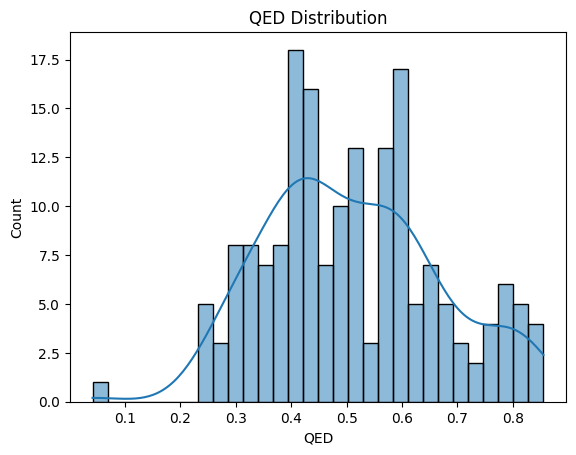

In [ ]:
# ============================================================
# QED Distribution
# ============================================================

plt.figure()
sns.histplot(df["QED"], bins=30, kde=True)
plt.title("QED Distribution")
plt.xlabel("QED")
plt.show()

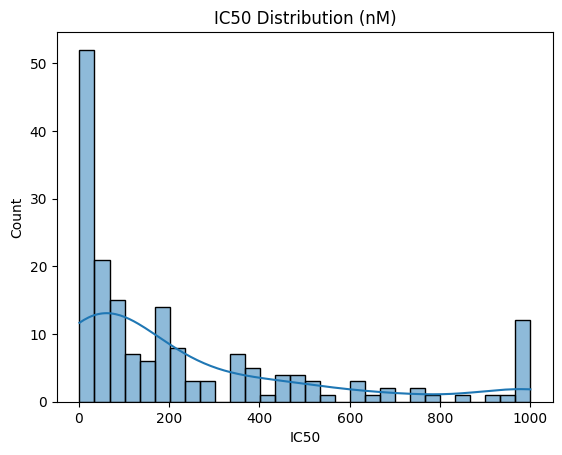

In [ ]:
# ============================================================
# IC50 Distribution
# ============================================================

plt.figure()
sns.histplot(df["Standard Value"], bins=30, kde=True)
plt.title("IC50 Distribution (nM)")
plt.xlabel("IC50")
plt.show()

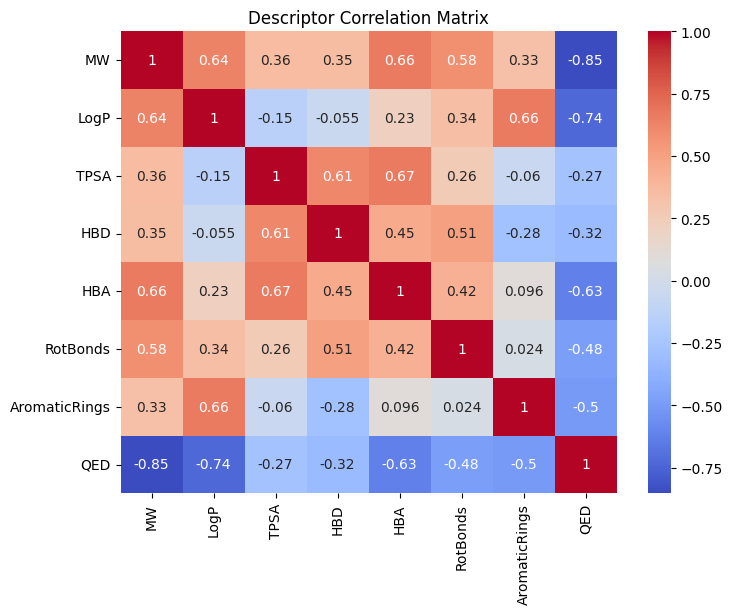

In [ ]:
# ============================================================
# Descriptor Correlation Matrix
# ============================================================

corr = df[[
    "MW","LogP","TPSA","HBD","HBA",
    "RotBonds","AromaticRings","QED"
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Descriptor Correlation Matrix")
plt.show()

In [ ]:
# ============================================================
# Extract Bemis-Murcko Scaffolds
# Bemis-Murcko Scaffold: A simplified representation of a molecule's core structure,
# consisting only of its rings and the atoms connecting them, excluding side chains.
# ============================================================

from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Chem.MolToSmiles(
            MurckoScaffold.GetScaffoldForMol(mol)
        )
    return None

df["Scaffold"] = df["Canonical_SMILES"].apply(get_scaffold)

df["Scaffold"].value_counts().head(10)

,count
Scaffold,
c1ncc2cc[nH]c2n1,14
c1ccc(-c2cc3c(-c4cnn(C5CCNCC5)c4)cncc3o2)cc1,12
O=C(Nc1ccc(C(=O)N2CCNCC2)cc1)c1csc2c(=O)[nH]cnc12,10
c1ccc(-c2cc(-c3cccnc3OC3CCCCC3)on2)nc1,8
c1cc2[nH]ncc2cc1-c1cnc2ccc(N3CCOCC3)nn12,6
c1ccc(Oc2ccnc(Nc3ccc(N4CCNCC4)cc3)n2)cc1,5
c1cc(-c2cc3c(-c4cnn(C5CCCCC5)c4)cncc3o2)c2snnc2c1,5
c1ccc(Nc2ccnc(Nc3ccc(N4CCNCC4)cc3)n2)cc1,4
O=C(c1cccc(Nc2ncc(-c3ccccc3)c(N[C@H]3C[C@@H]4C=C[C@H]3C4)n2)c1)N1CCCC1,4


In [ ]:
# ============================================================
# Scaffold Diversity
# The primary goal of this code segment is to assess the structural diversity of molecules
# in a dataset by counting the number of unique scaffolds present and comparing it to the
# total number of molecules.
# ============================================================

print("Unique scaffolds:", df["Scaffold"].nunique())
print("Total molecules:", len(df))

Unique scaffolds: 104
Total molecules: 178


In [ ]:
# ============================================================
# Generate Morgan Fingerprints
# ============================================================

from rdkit.Chem import AllChem

df["Fingerprint"] = df["Mol"].apply(
    lambda mol: AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
)

[09:18:47] DEPRECATION WARNING: please use MorganGenerator
[09:18:47] DEPRECATION WARNING: please use MorganGenerator
[09:18:47] DEPRECATION WARNING: please use MorganGenerator
[09:18:47] DEPRECATION WARNING: please use MorganGenerator
[09:18:47] DEPRECATION WARNING: please use MorganGenerator
[09:18:47] DEPRECATION WARNING: please use MorganGenerator
[09:18:47] DEPRECATION WARNING: please use MorganGenerator
[09:18:47] DEPRECATION WARNING: please use MorganGenerator
[09:18:47] DEPRECATION WARNING: please use MorganGenerator
[09:18:47] DEPRECATION WARNING: please use MorganGenerator
[09:18:47] DEPRECATION WARNING: please use MorganGenerator
[09:18:47] DEPRECATION WARNING: please use MorganGenerator
[09:18:47] DEPRECATION WARNING: please use MorganGenerator
[09:18:47] DEPRECATION WARNING: please use MorganGenerator
[09:18:47] DEPRECATION WARNING: please use MorganGenerator
[09:18:47] DEPRECATION WARNING: please use MorganGenerator
[09:18:47] DEPRECATION WARNING: please use MorganGenerat

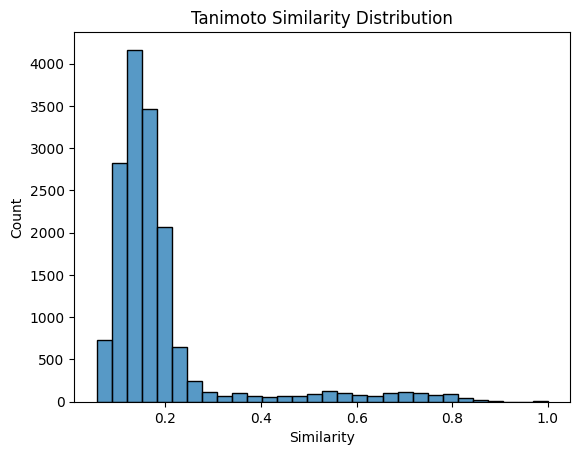

In [ ]:
# ================================================================
# Tanimoto Similarity Distribution
# quantify and visualize the chemical similarity between molecules
# within a dataset. This analysis helps in understanding the
# diversity and relatedness of compounds
# ================================================================

from rdkit.DataStructs import TanimotoSimilarity
import random

sample = df.sample(min(200, len(df)))

similarities = []

for i in range(len(sample)):
    for j in range(i+1, len(sample)):
        sim = TanimotoSimilarity(
            sample.iloc[i]["Fingerprint"],
            sample.iloc[j]["Fingerprint"]
        )
        similarities.append(sim)

plt.figure()
sns.histplot(similarities, bins=30)
plt.title("Tanimoto Similarity Distribution")
plt.xlabel("Similarity")
plt.show()

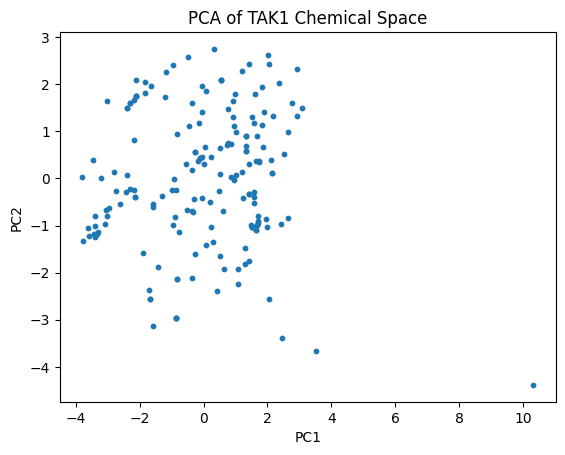

In [ ]:
# ============================================================
# PCA Visualization of Chemical Space
# The primary goal of this code is to apply PCA to a set of
# molecular descriptors, reducing their dimensionality to two
# principal components (PC1 and PC2). This section focuses on
# using PCA to project high-dimensional molecular descriptor data
# into a 2D space for visualization, allowing for an intuitive
# understanding of molecular diversity.
# ============================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = df[[
    "MW","LogP","TPSA","HBD","HBA",
    "RotBonds","AromaticRings","QED"
]]

scaled = StandardScaler().fit_transform(features)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

plt.figure()
plt.scatter(pca_result[:,0], pca_result[:,1], s=10)
plt.title("PCA of TAK1 Chemical Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
# ============================================================
# Final Summary Report
# ============================================================

print("="*50)
print("TAK1 DATASET SUMMARY")
print("="*50)

print("Total molecules:", len(df))
print("\nAverage MW:", df["MW"].mean())
print("Average LogP:", df["LogP"].mean())
print("Average TPSA:", df["TPSA"].mean())
print("Average QED:", df["QED"].mean())

print("\nMost common scaffolds:")
print(df["Scaffold"].value_counts().head(5))

TAK1 DATASET SUMMARY
Total molecules: 178

Average MW: 437.27175842696647
Average LogP: 3.4809112359550576
Average TPSA: 103.00483146067415
Average QED: 0.5102446355595486

Most common scaffolds:
Scaffold
c1ncc2cc[nH]c2n1                                     14
c1ccc(-c2cc3c(-c4cnn(C5CCNCC5)c4)cncc3o2)cc1         12
O=C(Nc1ccc(C(=O)N2CCNCC2)cc1)c1csc2c(=O)[nH]cnc12    10
c1ccc(-c2cc(-c3cccnc3OC3CCCCC3)on2)nc1                8
c1cc2[nH]ncc2cc1-c1cnc2ccc(N3CCOCC3)nn12              6
Name: count, dtype: int64
